# Notebook 2: Exploratory Data Analysis

Covers **Section 2** of the assignment:
1. Distribution of total Internet traffic across 10,000 areas
2. Identify top-3 areas; time series plots for 5 areas (first 2 weeks)
3. Two additional analyses on the highest-traffic area:
   - ACF / PACF
   - Seasonal decomposition + intraday/weekly patterns

In [1]:
import sys, os
sys.path.insert(0, '../src')

from data_loader import load_processed
from eda import run_full_eda

PROCESSED_DIR = '../data/processed/'
FIGURES_DIR   = '../report/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

matrix = load_processed(os.path.join(PROCESSED_DIR, 'traffic_matrix.parquet'))

Loaded processed matrix: (8928, 10000)  from ../data/processed/traffic_matrix.parquet


STEP 1: Traffic Distribution
Saved: fig1_traffic_distribution.png


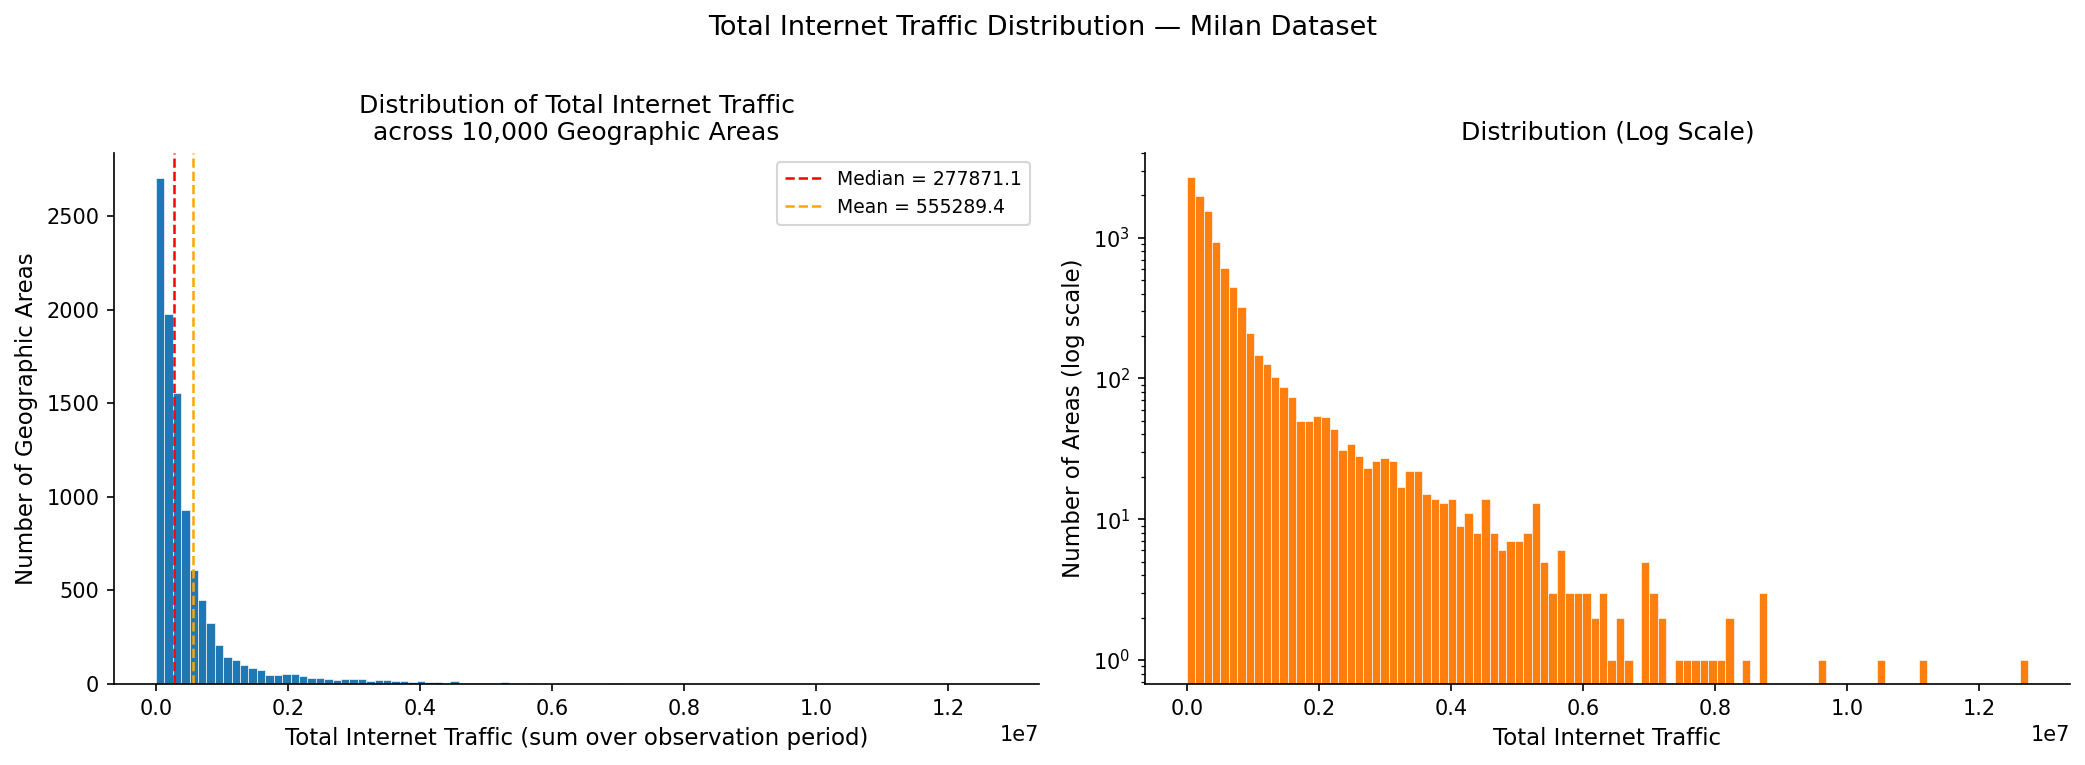


Traffic Distribution Summary
----------------------------------------
  Min    : 213.63
  25th % : 118101.98
  Median : 277871.09
  Mean   : 555289.38
  75th % : 577895.66
  Max    : 12740060.00
  Std    : 892595.69
  Skewness : 4.265

Top 3 areas by total Internet traffic:
  #1: Square 5161  —  total traffic = 12740060.00
  #2: Square 5059  —  total traffic = 11170854.00
  #3: Square 5259  —  total traffic = 10485780.00

STEP 2: Time Series Plots
Saved: fig2_time_series_5161_5059_5259_4159_4556.png


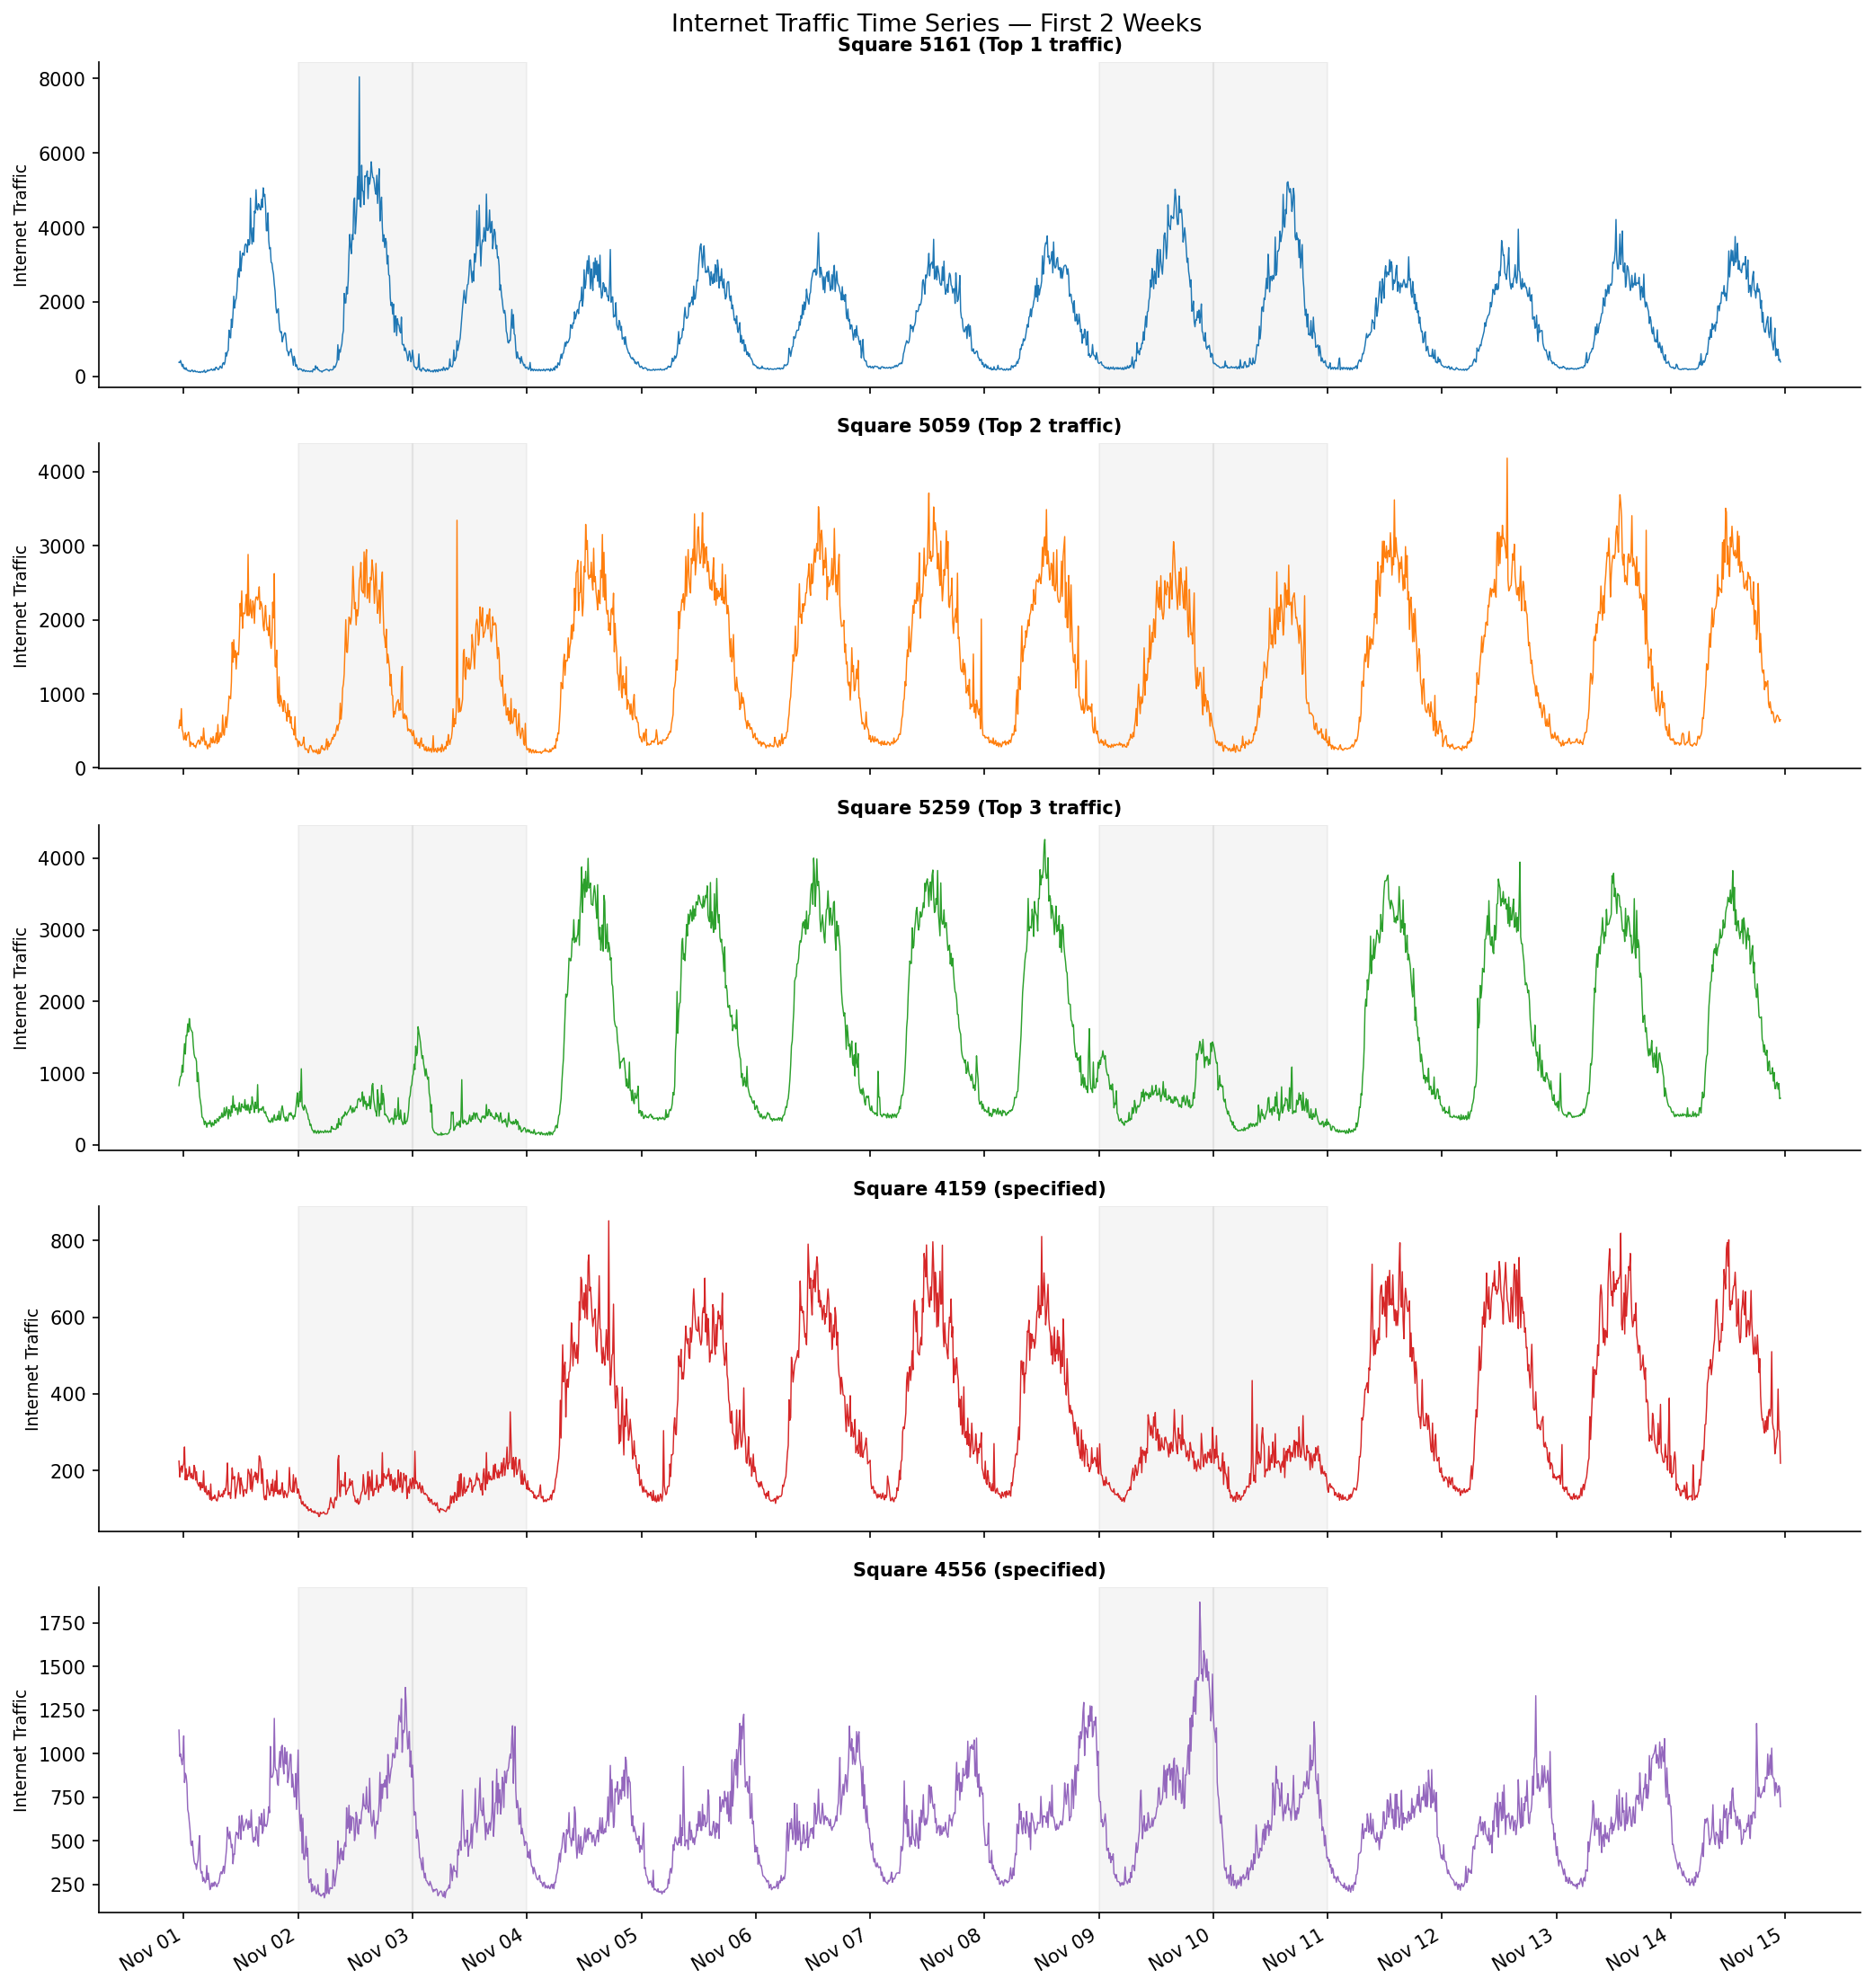


STEP 3: Additional Analyses — Square 5161
Saved: fig3_acf_pacf.png


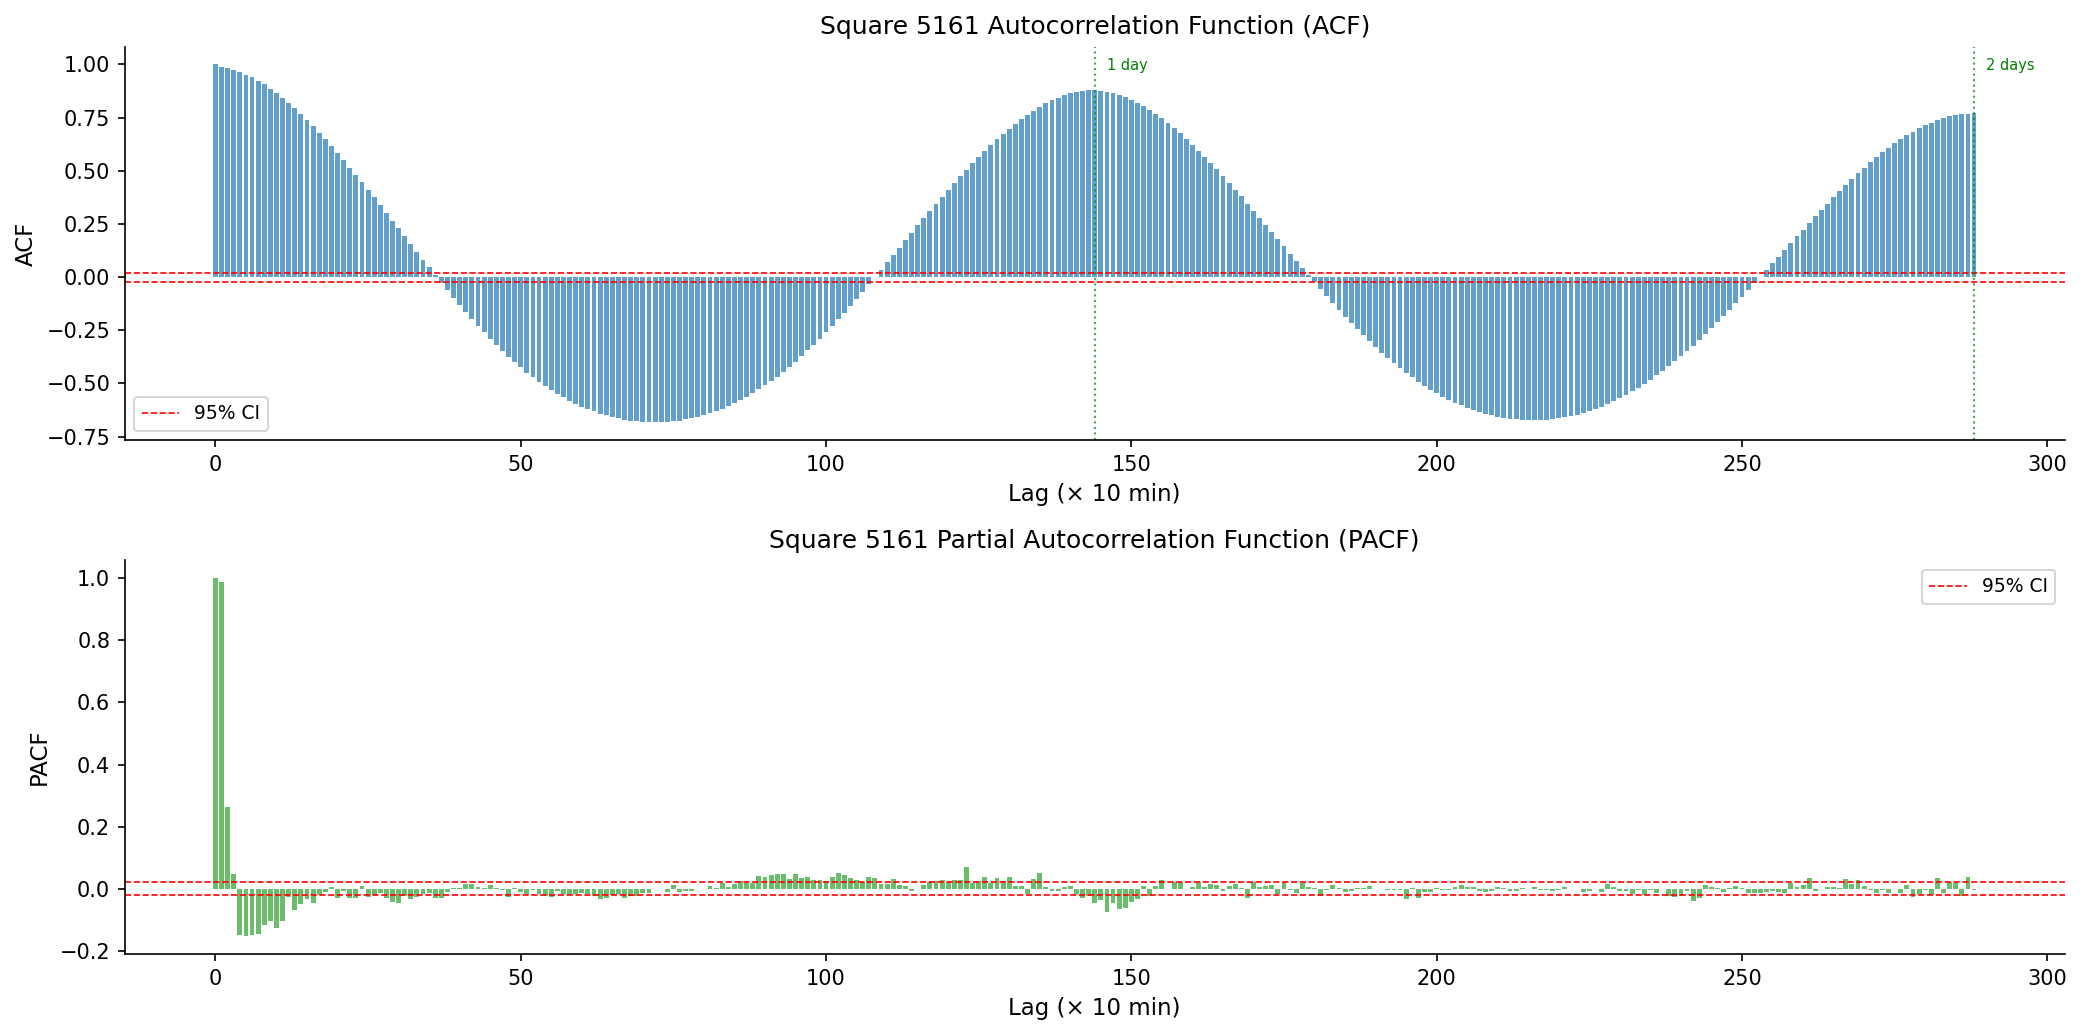

c:\Users\LENOVO\Downloads\milan_traffic_forecasting\notebooks\../src\eda.py:278: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomp = seasonal_decompose(s, model="additive", period=period, extrapolate_trend="freq")


Saved: fig4_seasonal_decomp.png


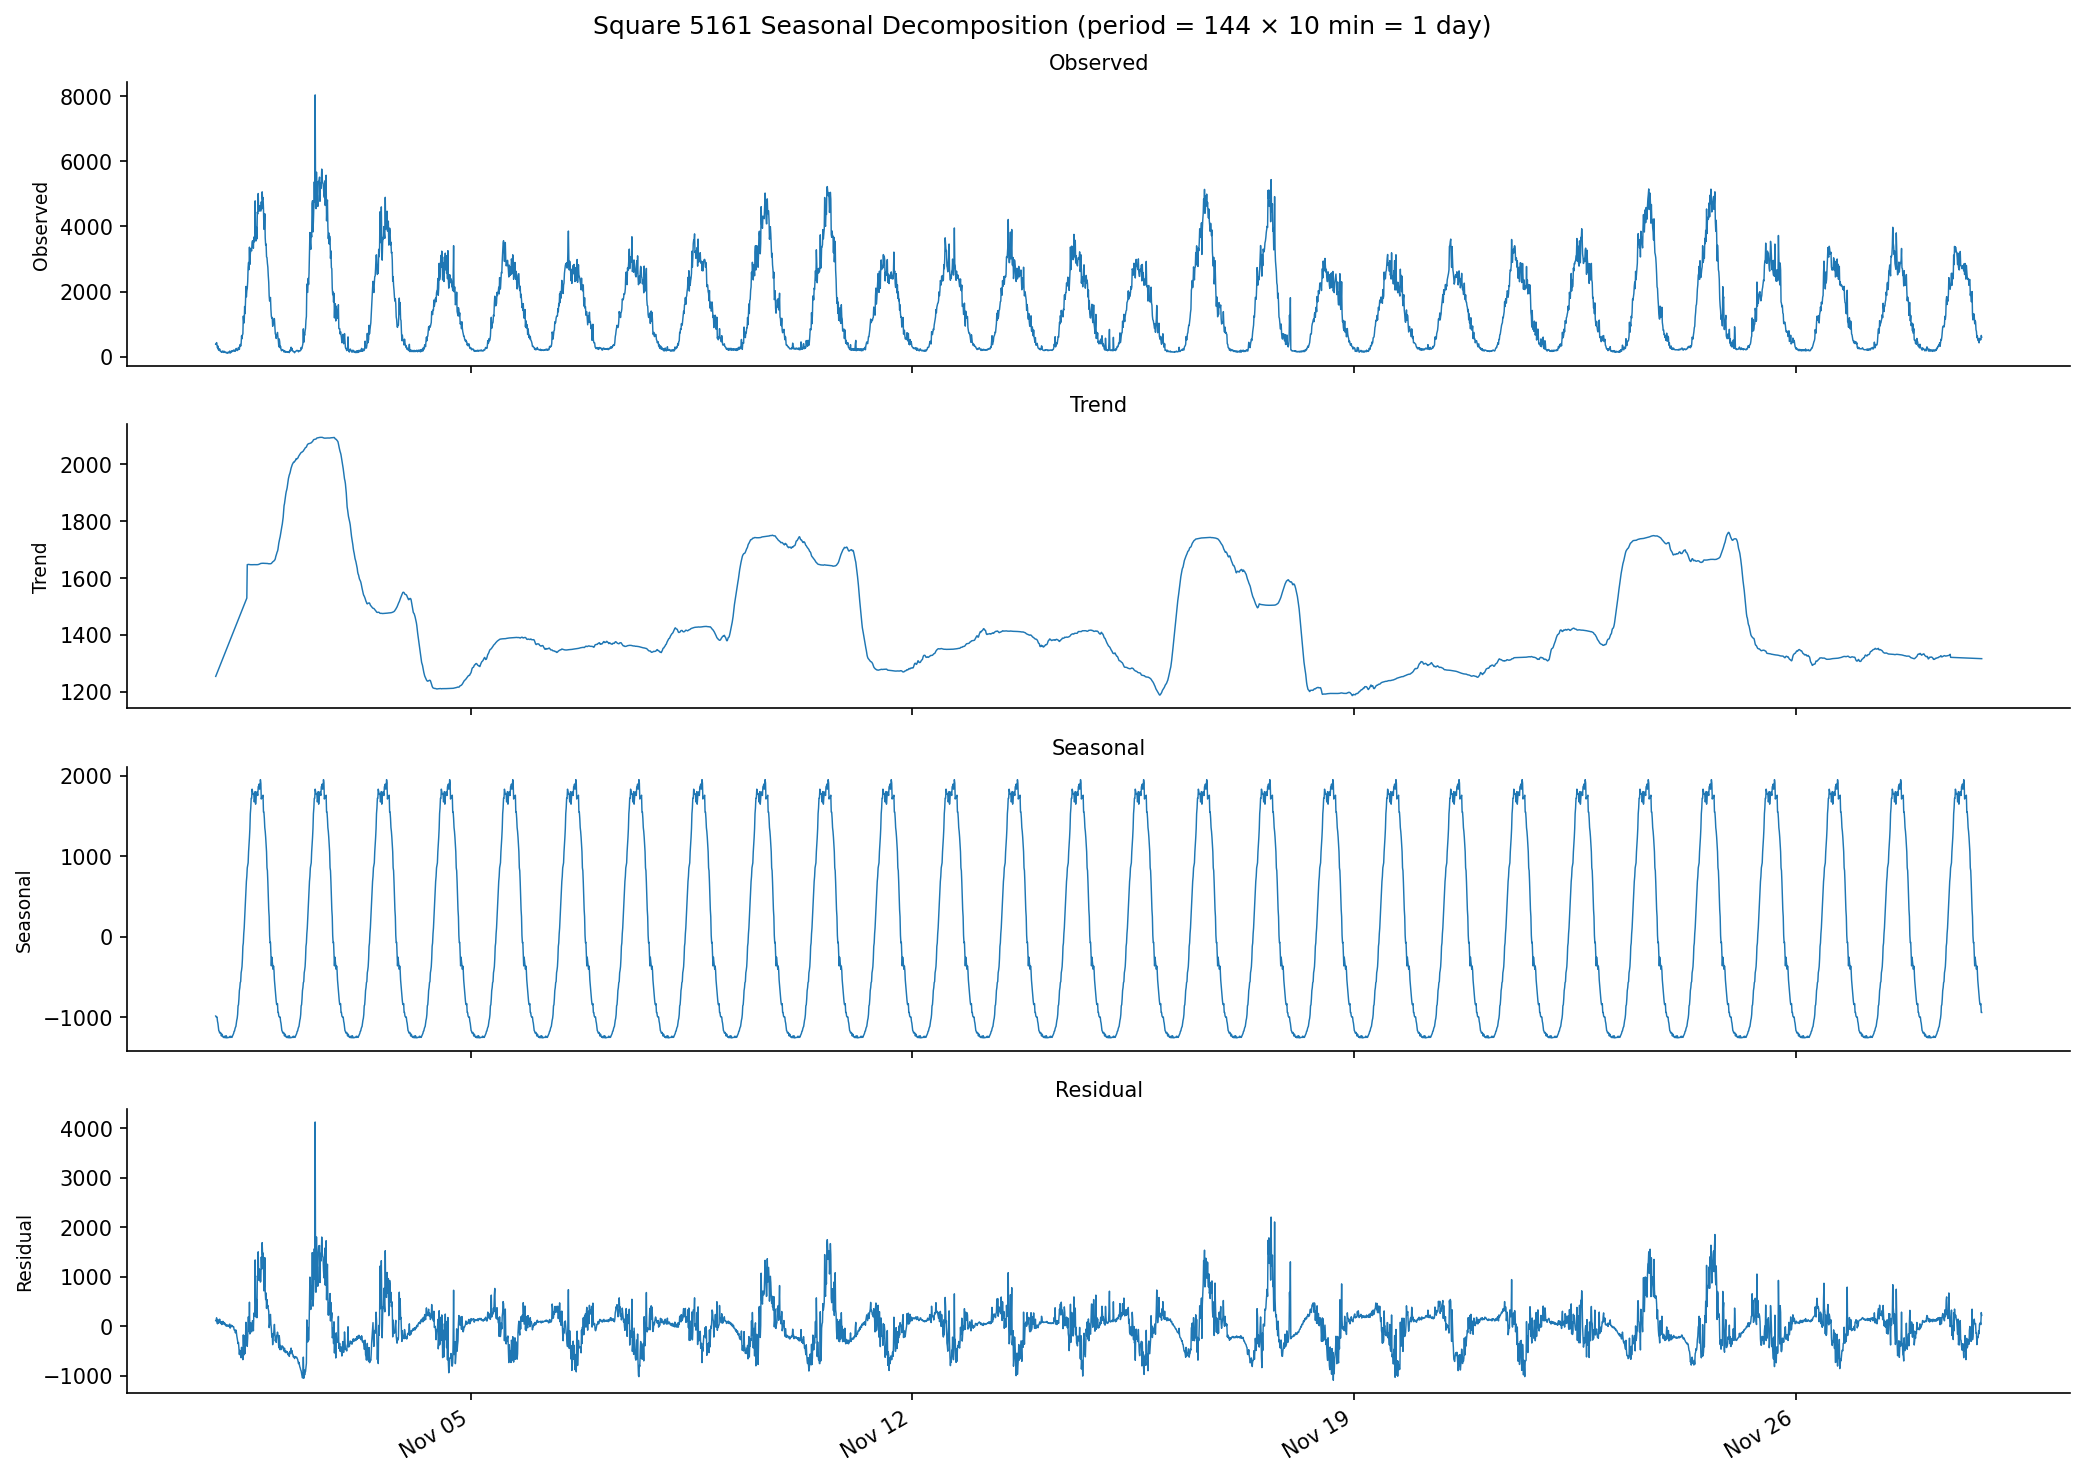

c:\Users\LENOVO\Downloads\milan_traffic_forecasting\notebooks\../src\eda.py:319: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(s, autolag="AIC")



ADF Stationarity Test — Square 5161
---------------------------------------------
  ADF Statistic : -19.0319
  p-value        : 0.000000
  Critical (1%) : -3.4311
  Critical (5%) : -2.8619
  Critical (10%) : -2.5669
  Verdict        : STATIONARY (α=0.05)
Saved: fig5_daily_weekly_pattern.png


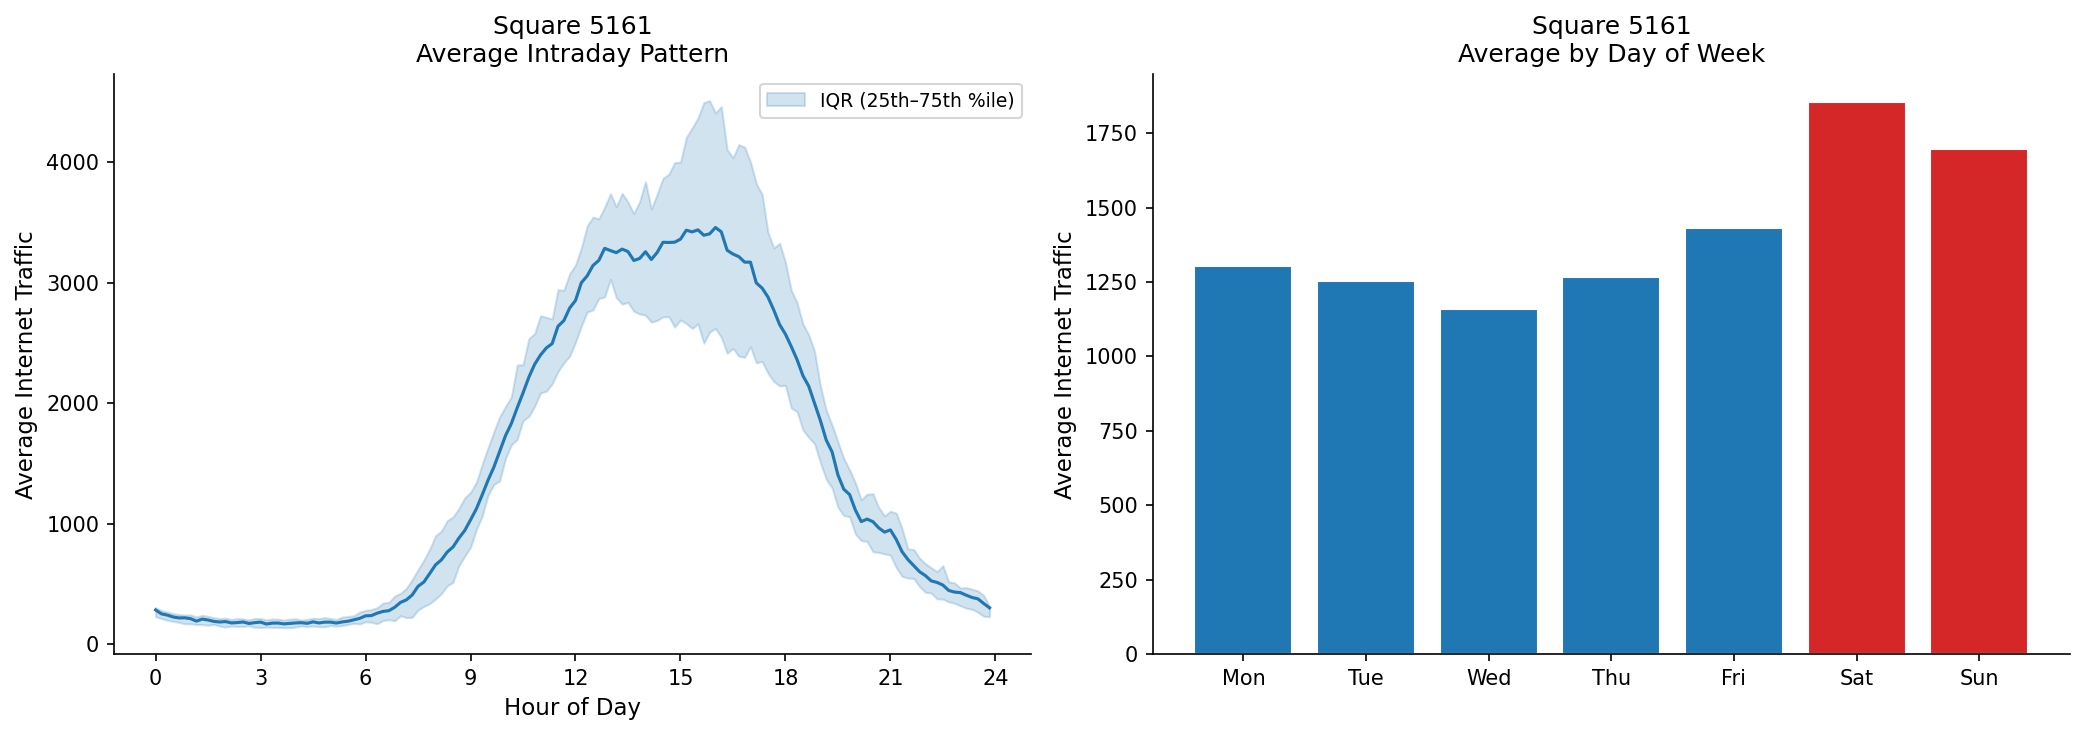


Top-3 areas: [5161, 5059, 5259]
Highest-traffic area: 5161


In [2]:
# Run the full EDA pipeline
# All figures are saved to FIGURES_DIR and displayed inline
eda_results = run_full_eda(matrix, save_dir=FIGURES_DIR)

print('\nTop-3 areas:', eda_results['top3'])
print('Highest-traffic area:', eda_results['top3'][0])

In [3]:
# Save top3 for use in subsequent notebooks
import json
with open(os.path.join(PROCESSED_DIR, 'top3_areas.json'), 'w') as f:
    json.dump({'top3': eda_results['top3']}, f)
print('Saved top3 areas.')

Saved top3 areas.
